# How to Define and Use a High-level Routine

This how-to guide walks you through the steps of defining a high-level routine (a Qubrick) and using it in a Workbench program. 

You can read more about the process in the tutorial [High-Level Routines: Qubricks](../tutorials/Qubricks.ipynb).

## Step 1. Create a routine class

The first step of defining a high-level routine in Workbench is defining a separate class that must be a subclass of class Qubrick.

```python
from psiqdk.workbench import Qubrick

class ReflectAboutMean(Qubrick):
    """Reflection about the uniform superposition of basis states from |0⟩ to |num_states-1⟩."""
    ...
```

## Step 2. (optional) Add constructor and helper methods

Like any Python class, a Qubrick can have a constructor (in case it needs any special initialization) and any helper methods necessary for its functioning. In this case, the Qubrick is initialized with an instance of uniform state preparation Qubrick that is stored as an instance variable for later use.

```python
    def __init__(self, state_prep: Qubrick, **kwargs):
        """
        Args:
            state_prep (Qubrick): A Qubrick implementing uniform state preparation subroutine"""
        self.state_prep = state_prep
        super().__init__(**kwargs)
```


## Step 3. Add _compute method

The `_compute` method of a Qubrick defines the core logic of performing the quantum routine. Here, it uses a mix of primitive gates and calls to the state preparation Qubrick stored as an instance variable.

```python
    def _compute(self, reg: Qubits, num_states: int) -> None:
        """Reflect the state of register `reg` about the uniform superposition of the first `num_states` basis states."""
        self.state_prep.compute(num_states, reg, dagger=True)
        (~reg).reflect()
        self.state_prep.uncompute()
```

## Step 4. Instantiate the class

The first step of using a high-level routine in Workbench is creating an instance of the class defined for it. Make sure to pass any constructor arguments, in this case, an instance of a uniform state preparation Qubrick.

```python
usp = ZAUSP()
reflect = ReflectAboutMean(usp)
```

## Step 5. Call the compute method

Once you have an instance of a Qubrick, you can apply it in your program by calling its `compute` method.

> Notice that it is *not* the same method as the `_compute` that spells out the logic of the routine! `compute` invokes the `_compute` method and additionally handles the infrastructure necessary for proper Qubricks execution.

```python
reflect.compute(reg, 3)
```


## Example

The following example defines and uses a high-level routine that reflects the state of the given register about a uniform superposition of the first `num_states` basis states.

|reg>
|0>    0.500000+0.000000j
|1>    0.500000+0.000000j
|2>    0.500000+0.000000j
|3>    0.500000+0.000000j
|reg>
|0>    -0.500000+0.000000j
|1>    -0.500000+0.000000j
|2>    -0.500000-0.000000j
|3>    0.500000+0.000000j


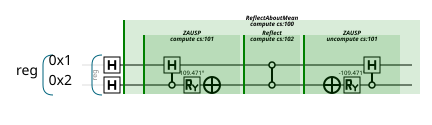

In [1]:
from psiqdk.workbench import QPU, Qubits, Qubrick
from psiqdk.workbench.usp import ZAUSP

class ReflectAboutMean(Qubrick):
    """Reflection about the uniform superposition of basis states from |0⟩ to |num_states-1⟩."""
    def __init__(self, state_prep: Qubrick, **kwargs):
        """
        Args:
            state_prep (Qubrick): A Qubrick implementing uniform state preparation subroutine"""
        self.state_prep = state_prep
        super().__init__(**kwargs)

    def _compute(self, reg: Qubits, num_states: int) -> None:
        """Reflect the state of register `reg` about the uniform superposition of the first `num_states` basis states."""
        # Adjoint of state prep
        self.state_prep.compute(num_states, reg, dagger=True)

        # Reflection about |0⟩
        (~reg).reflect()

        # State prep
        self.state_prep.uncompute()


qpu = QPU(num_qubits=2)
reg = Qubits(2, "reg", qpu)

usp = ZAUSP()
reflect = ReflectAboutMean(usp)

reg.had()
qpu.print_state_vector()

reflect.compute(reg, 3)   # Reflect about the state |0⟩ + |1⟩ + |2⟩
qpu.print_state_vector()

qpu.draw(show_qubricks=True)